# 6) Bayesian Networks

### Import Pickle File

In [1]:
import pickle

with open('finaldataset.pkl', 'rb') as file:
    data = pickle.load(file)

# Extract the components
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

cleaned_df = X_train.copy()
cleaned_df['Status'] = y_train

In [26]:
# Loadng the packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyAgrum as gum
import pyAgrum.lib.notebook as gnb
import pyAgrum.skbn as skbn
from sklearn.inspection import permutation_importance
from IPython.display import display, HTML

rs = 1234

### Train Naives Bayes Classifier

In [ ]:
# Learning structure and parameters automatically.
bnc = skbn.BNClassifier(learningMethod='NaiveBayes')
bnc.fit(X_train, y_train)

# Predicting outcomes
y_train_hat = bnc.predict(X_train)
y_test_hat = bnc.predict(X_test)

c:\Users\bloss\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


We first trained a Naive Bayes classifier. This model predicts loan default based on the idea that all features are conditionally independent given the outcome. After fitting it on the training data, we used it to make predictions on both the training and test sets. We’ll use those predictions later to evaluate how well the model actually performs.

### Creating the Bayesian Network

In [ ]:
# Showing label lines
bnc.bn.variable('credit_score').labels()

('(500;579[', '[579;659[', '[659;740[', '[740;820[', '[820;900)')

This line shows the label ranges that the model created for credit scores. Since Bayesian Networks can’t handle continuous numbers directly, the credit score was split into intervals or bins. These bins help the model reason about how likely someone is to default based on which score range they fall into.

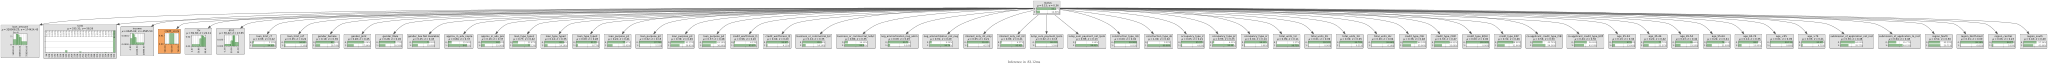

None


None

In [25]:
# Show Inference and Bayesian Network
gnb.showBN(bnc.bn)
display(gnb.sideBySide(gnb.showInference(bnc.bn, evs={'credit_score': '[579;659['})))


# Ajusting the default graph size to make it easier to read
gum.config['notebook', 'default_graph_size'] = '150'
gum.config['notebook', 'default_graph_inference_size'] = '150'

This graph shows how the Bayesian Network connects different features. Each circle is a feature, and the arrows show which features are directly related to each other based on the training data.

Below the graph, we ran an inference query to estimate the distribution of loan default probability given a credit score in the range 579 - 659. This helps us interpret how specific inputs affect model beliefs about default risk.

The output from that inference probably shows a higher probability of default (Status = 1) when credit scores fall in the [579;659[ range (which is a below-average range in our dataset).

Since lower credit scores typically indicate worse credit history, which increases the risk of default, the model has learned the pattern and reflects it in the probabilities given.

The inference shows that the chance of default goes up when credit scores are in this lower range. That means the model has picked up on the relationship between credit score and risk — just like in the real world, people with lower credit scores are more likely to miss payments or default.

### Permutaiton Importance

In [ ]:
# Permutation Importance 
from sklearn.ensemble import RandomForestClassifier

# Fit fast model for feature importance
rf = RandomForestClassifier(n_estimators=50, random_state=0)
rf.fit(X_train, y_train)

# Compute permutation importance (much faster)
perm_import = permutation_importance(
    rf,
    X_train,
    y_train,
    n_repeats=5,
    random_state=0
)

c:\Users\bloss\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Since running permutation importance with the Bayesian Network was taking way too long (over 45 minutes just for a few features), we switched to a RandomForestClassifier to speed things up.

Random Forests are much faster and still give a realtively accurate estimate of which features are most important. We trained the model on the same data and then used permutation importance to measure how much each feature affects prediction accuracy. This helps us figure out which inputs really matter in deciding whether someone defaults.

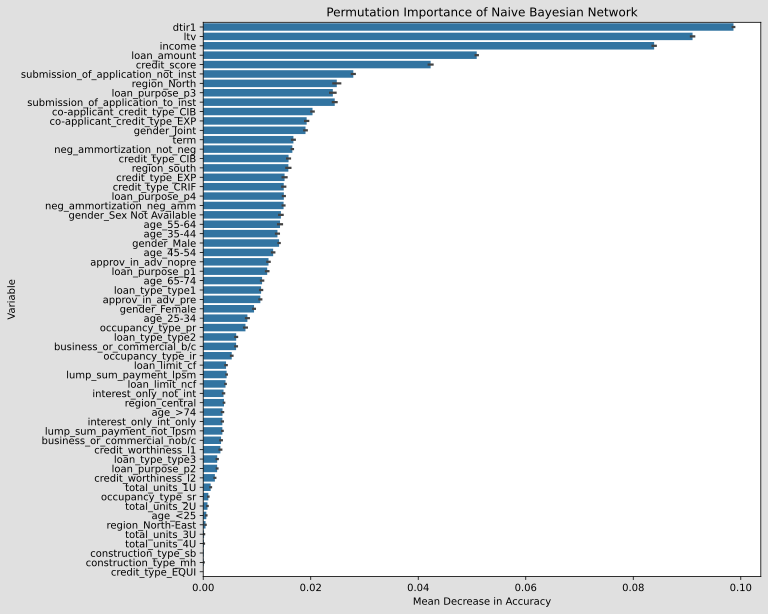

In [22]:
# Plotting the graph
X1 = X_train.copy()

perm_import_df = pd.DataFrame(perm_import['importances'].transpose(),
                              columns=X1.columns.tolist())

perm_import_df_mlt = perm_import_df.melt(value_vars=X1.columns.tolist(),
                                         var_name='Variable',
                                         value_name='Importance').sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 10))

sns.barplot(data=perm_import_df_mlt, 
            y='Variable', 
            x='Importance', 
            errorbar='sd')

plt.title("Permutation Importance of Naive Bayesian Network")
plt.xlabel("Mean Decrease in Accuracy")

plt.show()

The most important feature in predicting whether someone defaults is their credit score, as lower scores usually mean more risk, which is seen in the Bayesian Network. Right behind that is income, which affects a person’s ability to repay. Other useful features were whether the loan is a Type 1 loan, if the borrower rents their home, and if the loan has a short term. These all showed noticeable drops in accuracy when shuffled, meaning the model relies on them heavily.

Overall: The most important features turned out to be credit score and income, followed by loan type and whether someone rents their home. These features had the biggest impact on prediction accuracy. This lines up with real-world expectations — people with lower credit scores, lower income, or less secure loan terms tend to default more often.